# Modell-Inspektion
Vorhersagen verschiedener Runs auf ungefärbten Tiles vergleichen

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os
from smallunet import Unet
import random

In [11]:
# ── Einstellungen ─────────────────────────────────────────────────
cwd        = Path.cwd().parent.parent
img_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
ungef_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/ungef'
res_dir    = Path('res')

# Runs die verglichen werden sollen
runs = [
    #"MaskedGauss",
    #"LR4E10",
    #"LR3E100",
    #"smallbs64",
    #"smallbs16",
    #"smallbs16lr5e3",
    #"smallbs16lr5e3epoch1000",
    #"smallbs16lr1e3epoch1000",
    "smallbs16lr1e3epoch2000",
    "smallbs16lr1e3epoch3000",
    "defbs16lr1e3epoch2000",
    
]

n_tiles    = 6      # wie viele Tiles angezeigt werden
threshold  = 0.35    # Schwellwert für Binärmaske
device     = torch.device('cpu') # 'cuda' if torch.cuda.is_available() else 
print(f'Device: {device}')

Device: cpu


In [12]:
# ── Modelle laden ─────────────────────────────────────────────────
models = {}
for run in runs:
    model_path = res_dir / run / 'last_model.pth'
    if not model_path.exists():
        print(f'⚠ {run}: last_model.pth nicht gefunden')
        continue
    state_dict = torch.load(model_path, map_location=device)

    state_dict = {
        k.replace("_orig_mod.", ""): v
        for k, v in state_dict.items()
    }
    m = Unet().to(device)
    m.load_state_dict(state_dict)
    m.eval()
    models[run] = m
    print(f'✓ {run} geladen')

print(f'\n{len(models)} Modelle geladen.')

✓ smallbs16lr1e3epoch2000 geladen
✓ smallbs16lr1e3epoch3000 geladen
✓ defbs16lr1e3epoch2000 geladen

3 Modelle geladen.


In [13]:
# ── Tiles laden ───────────────────────────────────────────────────
valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
# tile_paths = sorted([
#     p for p in img_dir.iterdir()
#     if p.suffix.lower() in valid_ext
# ])[:n_tiles]


all_tiles = sorted([
    p for p in img_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

ungef_tiles = sorted([
    p for p in ungef_dir.iterdir()
    if p.suffix.lower() in valid_ext
])

tile_paths = random.sample(all_tiles, n_tiles)
mask_paths = [
    Path(str(p).replace("/img/", "/mask/"))
    for p in tile_paths
]
print(f'{len(tile_paths)} Tiles gefunden.')

def load_tile(path):
    img = Image.open(path).convert('L')
    t   = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0
    return t

def predict(model, tile):
    with torch.no_grad():
        inp = tile.unsqueeze(0).to(device)
        out = model(inp)
        prob = torch.sigmoid(out).squeeze().numpy()
    return prob

6 Tiles gefunden.


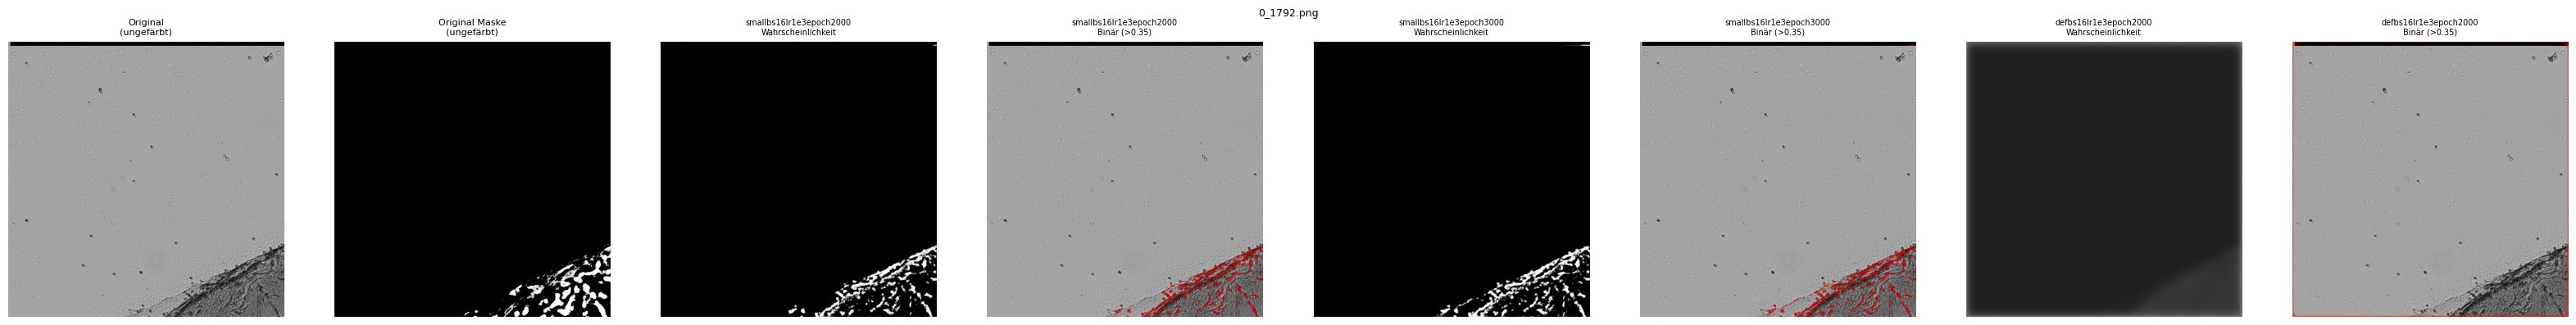

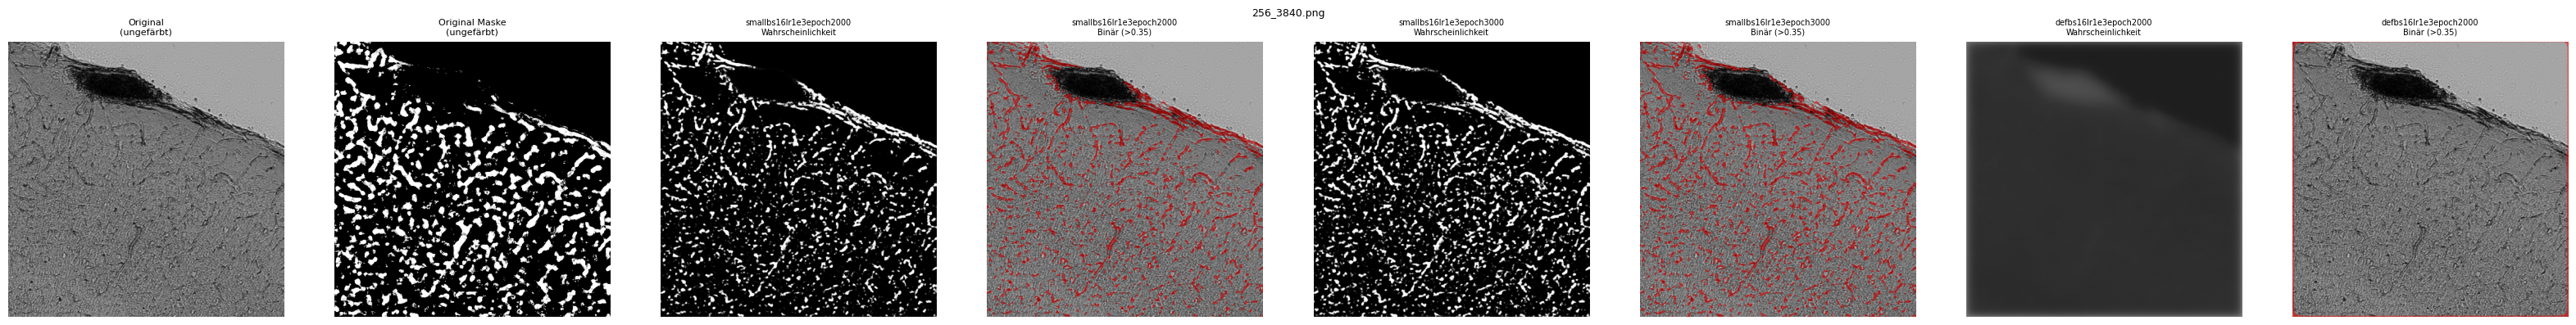

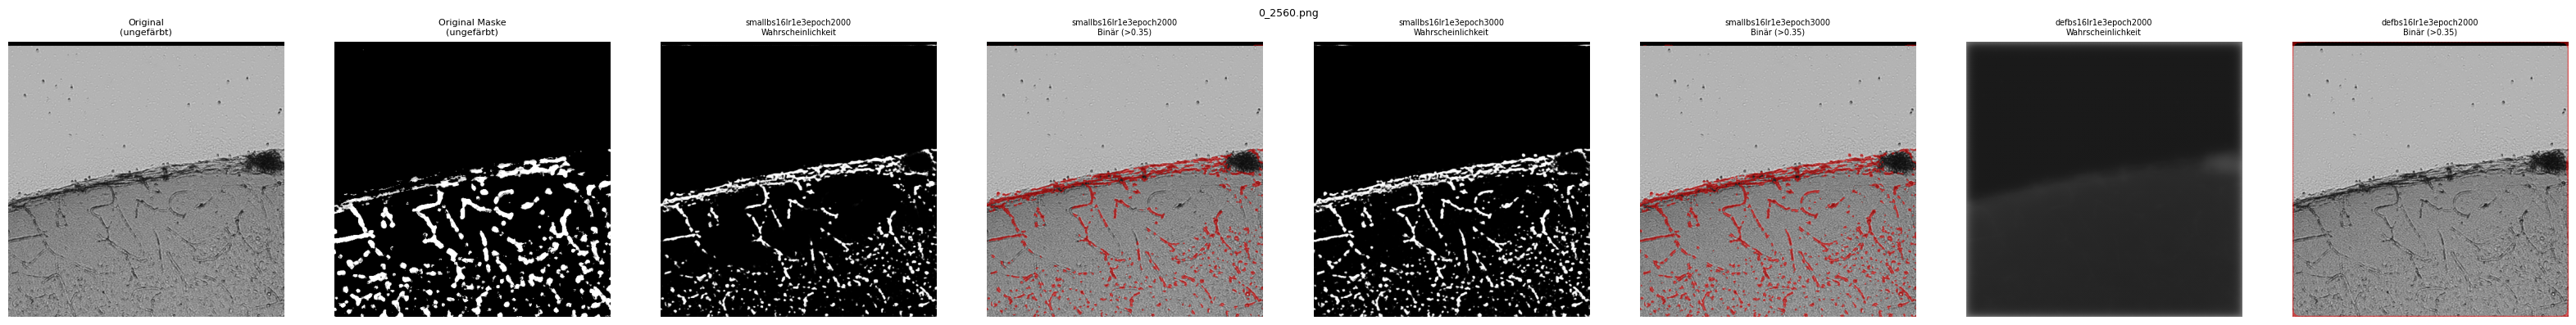

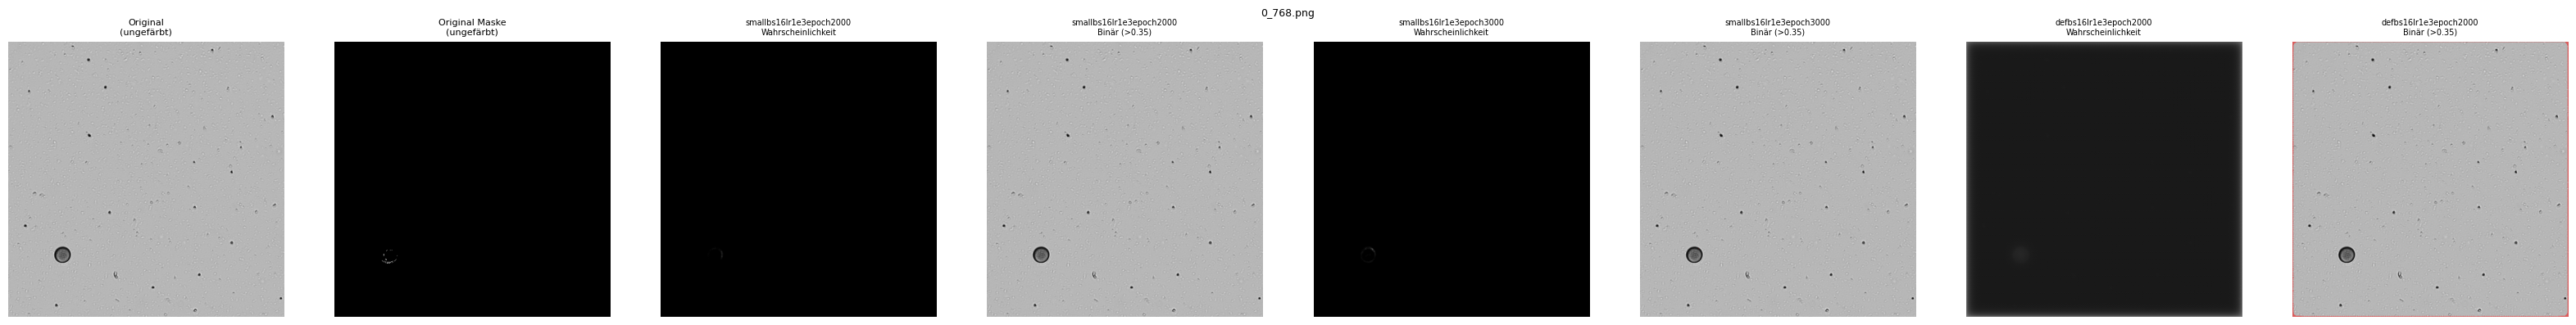

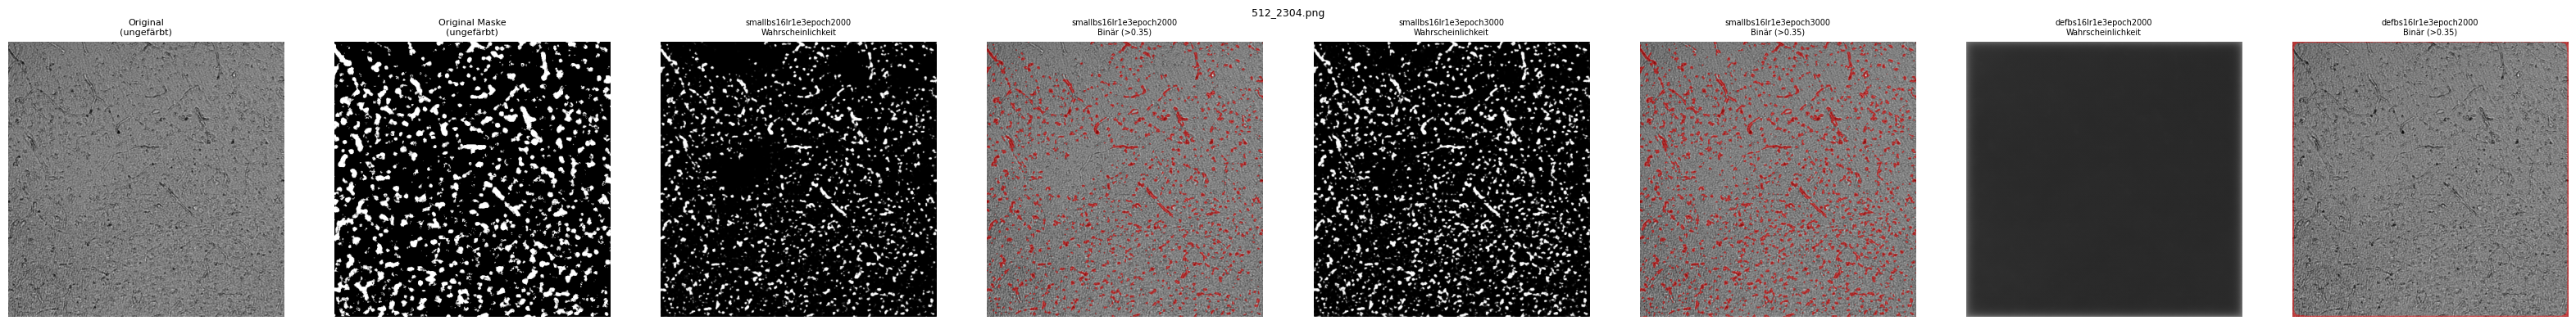

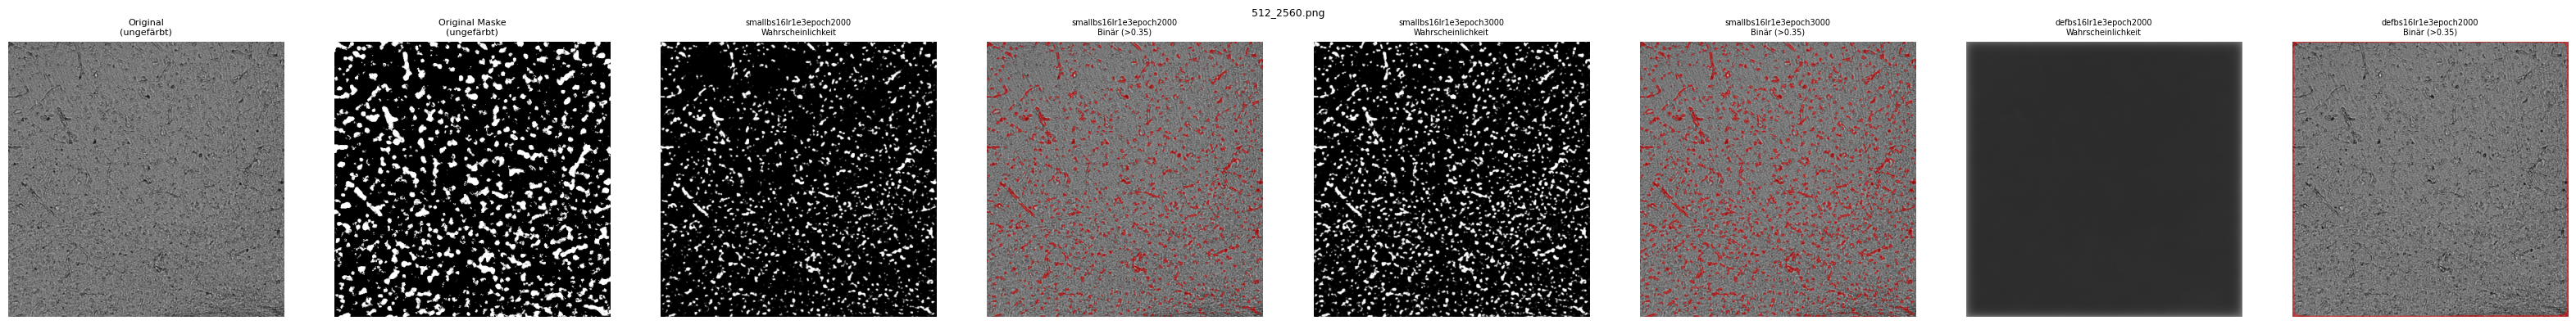

In [14]:
# ── Visualisierung ────────────────────────────────────────────────
n_cols = 2 + len(models) * 2  # Bild + Soll-Mask + (prob + binary) pro Modell

for tile_path, mask_path in zip(tile_paths, mask_paths):
    tile = load_tile(tile_path)
    mask = load_tile(mask_path)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    # Original
    axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original\n(ungefärbt)', fontsize=8)
    axes[0].axis('off')
    
    axes[1].imshow(mask.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Original Maske\n(ungefärbt)', fontsize=8)
    axes[1].axis('off')
    
    ungef_tiles
    
    # Vorhersagen
    for i, (run, model) in enumerate(models.items()):
        if tile.shape != (1, 512, 512):
            continue
        prob   = predict(model, tile)
        binary = (prob > threshold).astype(float)

        ax_prob   = axes[2 + i * 2]
        ax_binary = axes[3 + i * 2]

        ax_prob.imshow(prob, cmap='gray', vmin=0, vmax=1)
        ax_prob.set_title(f'{run}\nWahrscheinlichkeit', fontsize=7)
        ax_prob.axis('off')

        ax_binary.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        overlay = np.zeros((*binary.shape, 4))
        overlay[..., 0] = 1.0
        overlay[..., 3] = binary * 0.5
        ax_binary.imshow(overlay)
        ax_binary.set_title(f'{run}\nBinär (>{threshold})', fontsize=7)
        ax_binary.axis('off')

    plt.suptitle(tile_path.name, fontsize=9)
    plt.tight_layout()
    plt.show()

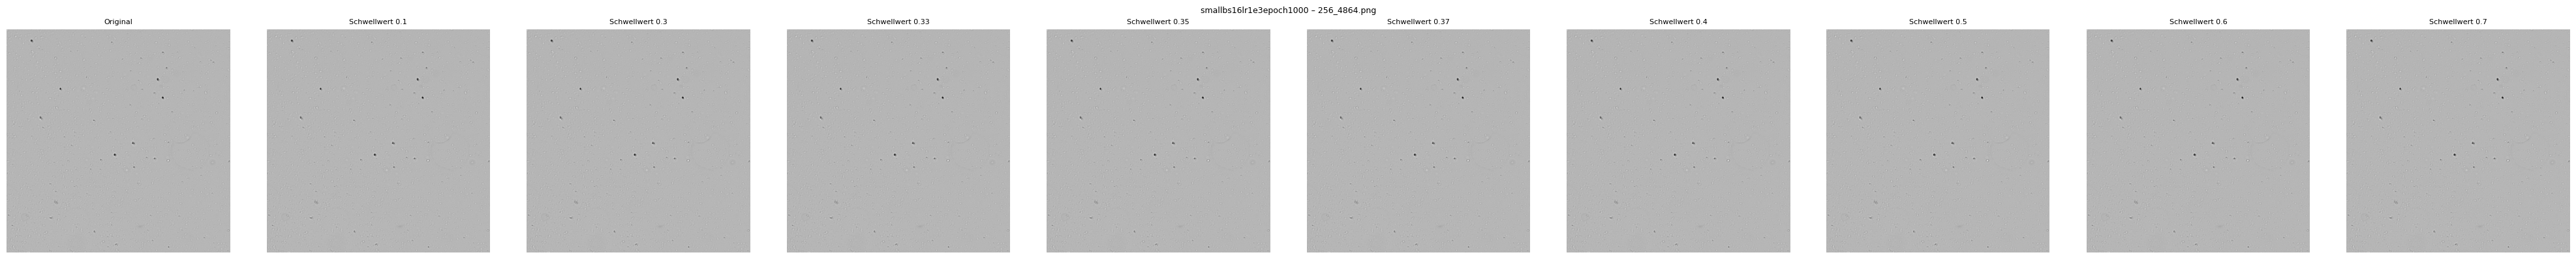

In [16]:
# ── Schwellwert interaktiv anpassen ──────────────────────────────
# Einzelnes Tile mit verschiedenen Schwellwerten anschauen
tile_idx   = 5   # welches Tile
run_name   = runs[1]  # welches Modell
thresholds = [0.1,0.3,0.33,0.35,0.37, 0.4, 0.5, 0.6, 0.7]

tile  = load_tile(tile_paths[tile_idx])
prob  = predict(models[run_name], tile)

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(4*(len(thresholds)+1), 4))
axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=8)
axes[0].axis('off')

for ax, t in zip(axes[1:], thresholds):
    binary = (prob > t).astype(float)
    ax.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    overlay = np.zeros((*binary.shape, 4))
    overlay[..., 0] = 1.0
    overlay[..., 3] = binary * 0.5
    ax.imshow(overlay)
    ax.set_title(f'Schwellwert {t}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'{run_name} – {tile_paths[tile_idx].name}', fontsize=9)
plt.tight_layout()
plt.show()

# Tests

In [17]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

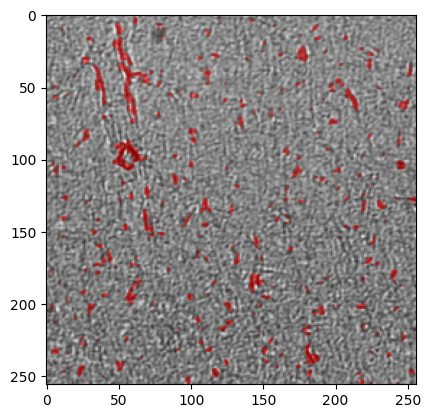

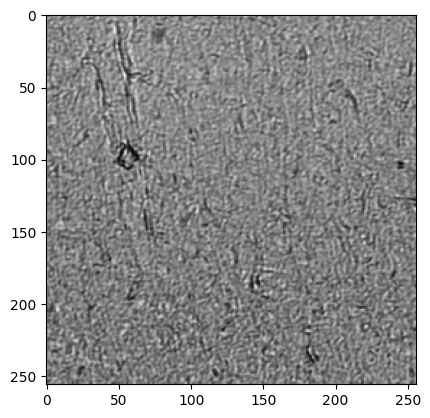

In [22]:
tile = load_tile("/run/media/tim/SSD1TB/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/ungef/PE-2024-01126-M_00_s0021_PM_Complete_Transmittance_Stitched_Flat_v004_512_2176.png")
mask = load_tile(mask_paths[tile_idx])
plt.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
run_name   = runs[3]
threshold = 0.9
model = models[run_name]
prob   = predict(model, tile)
binary = (prob > threshold).astype(float)

overlay = np.zeros((*binary.shape, 4))
overlay[..., 0] = 1.0
overlay[..., 3] = binary * 0.5
plt.imshow(overlay.squeeze())
plt.show()

plt.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        

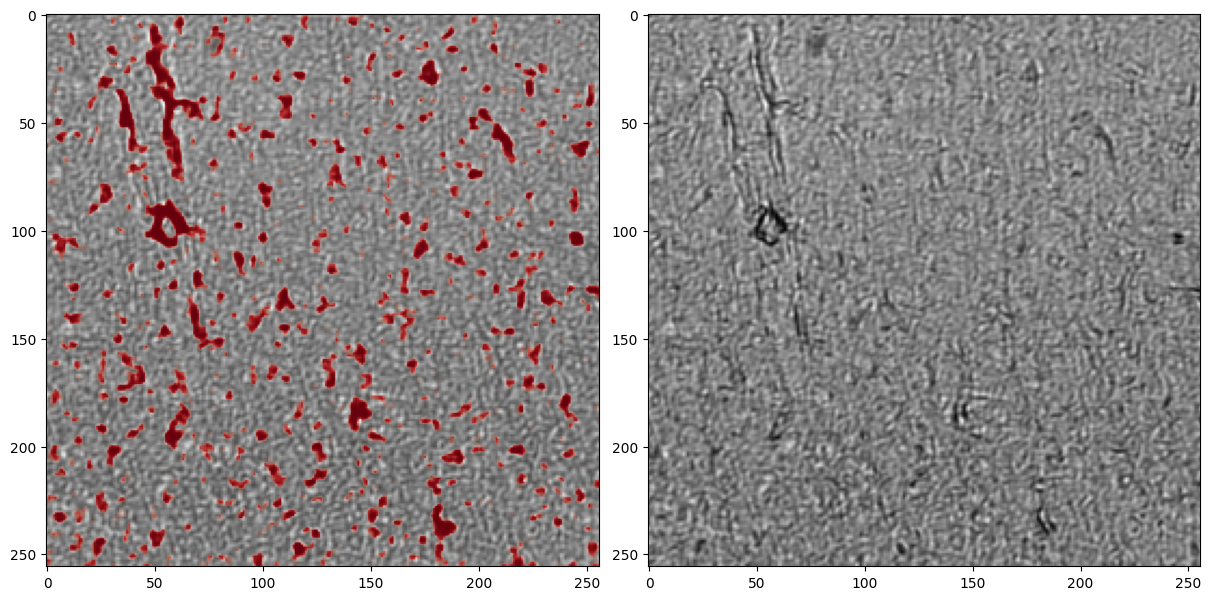

In [23]:
tile = load_tile("/run/media/tim/SSD1TB/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/ungef/PE-2024-01126-M_00_s0021_PM_Complete_Transmittance_Stitched_Flat_v004_512_2176.png")
mask = load_tile(mask_paths[tile_idx])



fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 6),
    constrained_layout=True
)
ax1.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
im = ax1.imshow(
    prob,
    cmap="Reds",      # oder "viridis", "turbo", "plasma", ...
    alpha=prob,       # Transparenz
    vmin=0,
    vmax=1,
)
# Colorbar hinzufügen
cbar = fig.colorbar(im, ax=ax,  orientation="horizontal")
ax2.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
plt.show()


In [64]:
transforms.ToTensor()

NameError: name 'transforms' is not defined

In [1]:
import torch
from torch import nn, optim
from unet import Unet, dice_loss
from dataset import dataloader
from aug import load_augmentation
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import json
import argparse
# New
from torch.amp import autocast, GradScaler

In [ ]:
from torch.utils.data import Dataset, DataLoader
from aug.ClaudeAug import *
from aug.ClaudeDataloader import *

class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask  = Image.open(self.mask_paths[idx])              # Graustufen / P-Mode

        if self.transform:
            image, mask = self.transform(image, mask)

        return image, mask

# Augmentation-Pipeline
train_transform = JointCompose([
    JointResize(256),
    JointRandomHorizontalFlip(p=0.5),
    JointRandomVerticalFlip(p=0.5),
    JointRandomRotation(degrees=30),
    JointRandomResizedCrop(size=256, scale=(0.7, 1.0)),
    JointColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    JointGaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    JointToTensor(),
    JointNormalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
])

val_transform = JointCompose([
    JointResize(256),
    JointToTensor(),
    JointNormalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
])

print("Pipeline ready:")
print(train_transform)
# Mit separaten Ordnern:
# train_loader, val_loader = get_dataloaders(
#     images_dir     = "dat/images/train",
#     masks_dir      = "data/masks/train",
#     val_images_dir = "data/images/val",
#     val_masks_dir  = "data/masks/val",
#     batch_size=16, image_size=512,
# )

# Mit automatischem Split:
train_dataloader, val_dataloader = get_dataloaders(
    images_dir = "dat/train/img",
    masks_dir  = "dat/train/mask",
    val_split  = 0.15,
    batch_size=16, image_size=512,
    train_transform=train_transform, val_transform=val_transform,
)

Pipeline ready:
JointCompose([
])
────────────────────────────────────────────────
  Segmentation DataLoader  
────────────────────────────────────────────────
  Train-Samples :    708
  Val-Samples   :    124
  Batch-Size    :     16
  Train-Batches :     44
  Val-Batches   :      8
────────────────────────────────────────────────


In [ ]:
def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--run_name",     type=str, required=True)
    parser.add_argument("--epochs",       type=int, default=100)
    parser.add_argument("--bs",           type=int, default=16)
    parser.add_argument("--lr",           type=float, default=1e-3)
    parser.add_argument("--worker",           type=int, default=1)
    args = parser.parse_args()
    
    cwd = Path(os.getcwd()).parent.parent
    # img_path      = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/train/img'
    # mask_path     = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/train/mask'
    # img_val_path  = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
    # mask_val_path = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/mask'

    out_dir = Path("res") / args.run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    if torch.cuda.is_available():
        device = torch.device("cuda")
    else: # Windows alternative zu cuda, schon deutlich schneller, ca faktor 5 schneller
        # natürlich immernoch deutlich langsamer als cuda wenn es funktionieren würde D:
        import torch_directml
        device = torch_directml.device()
    
    use_amp = device.type == "cuda"
    # Augmentation-Pipeline
    train_transform = JointCompose([
        JointResize(256),
        JointRandomHorizontalFlip(p=0.5),
        JointRandomVerticalFlip(p=0.5),
        JointRandomRotation(degrees=30),
        JointRandomResizedCrop(size=256, scale=(0.7, 1.0)),
        JointColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        JointGaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        JointToTensor(),
        JointNormalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        JointMaskedGauss(sigmaLow=0.5, sigmaUpper=1.0)
    ])

    val_transform = JointCompose([
        JointResize(256),
        JointToTensor(),
        JointNormalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
    ])
    # Daten Laden, Worker, Batch etc und augmentation festlegen
    train_dataloader, val_dataloader = get_dataloaders(
        images_dir = "dat/train/img",
        masks_dir  = "dat/train/mask",
        val_split  = 0.15,
        batch_size=args.bs, image_size=512,
        train_transform=train_transform, val_transform=val_transform,
        num_workers=args.worker,
        image_mode="L", mask_mode="L",
        prefetch=4,
    )
    
    model = Unet().to(device)
    model = model.to(memory_format=torch.channels_last)
    model = torch.compile(model)  # einmalig vor dem Training (Test) ,mode="reduce-overhead"
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    criterion = torch.nn.BCEWithLogitsLoss()
    # torch.backends.cudnn.benchmark = True
    
    with open(out_dir / "config.json", "w") as f:
        json.dump(vars(args), f, indent=2)

    train_log = []
    best_val_loss = float('inf')
    scaler = GradScaler(enabled=use_amp)

    optimizer.zero_grad(set_to_none=True)
    for epoch in tqdm(range(args.epochs)):
        model.train()
        epoch_loss = 0.0

        for i, batch in tqdm(enumerate(train_dataloader), leave=False):

            images, masks = batch
            images, masks = images.to(device, non_blocking=True, memory_format=torch.channels_last), masks.to(device, non_blocking=True,)
            with autocast(device_type=device.type, enabled=use_amp):
                output =  model(images) # torch.sigmoid(model(imgs))
                loss = criterion(output, masks) + dice_loss(output, masks)# criterion(outputs, masks) + dice_loss(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            epoch_loss += loss.item()
        epoch_loss /= len(train_dataloader)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_imgs, val_masks in tqdm(val_dataloader, leave=False):
                val_imgs, val_masks = val_imgs.to(device, non_blocking=True, memory_format=torch.channels_last), val_masks.to(device, non_blocking=True)
                with autocast(device_type=device.type, enabled=use_amp):
                    val_outputs = model(val_imgs)
                    loss_v = (
                        criterion(val_outputs, val_masks)
                        + dice_loss(val_outputs, val_masks)
                    )
                val_loss += loss_v.item()
        val_loss /= len(val_dataloader)

        train_log.append([epoch_loss, val_loss])

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), out_dir / "best_model.pth")

        log_arr = np.array(train_log).T
        #plt.plot(log_arr[0], label='train_loss')
        #plt.plot(log_arr[1], label='val_loss')
        #plt.legend()
        #plt.title(f'{epoch+1}/{args.epochs} | aug: {args.augmentation}')
        #plt.savefig(out_dir / 'train_log.png')
        #plt.clf()

        print(f'{epoch+1}/{args.epochs} | train: {epoch_loss:.4f} | val: {val_loss:.4f}')
                    # _orig_mod ist wegen dem torch.compile(model) ein präfix der den parametern hinzugefügt wird 
                    # und beim einlesen der parameter stört
    torch.save(model._orig_mod.state_dict(), out_dir / "last_model.pth")
    # np.save(out_dir / "train_log.npy", np.array(train_log))
    log_arr = np.array(train_log).T
    with open(out_dir / "train_log.json", "w") as f:
        json.dump({
            "train_loss": log_arr[0].tolist(),
            "val_loss":   log_arr[1].tolist()
        }, f, indent=2)
    plt.plot(range(1, args.epochs + 1), log_arr[0], label='train_loss')
    plt.plot(range(1, args.epochs + 1), log_arr[1], label='val_loss')
    plt.legend()
    plt.title(f'{epoch+1}/{args.epochs} | aug: {args.augmentation}')
    plt.savefig(out_dir / 'train_log.png')
    plt.clf()

if __name__ == "__main__":
    main()